# Income Analysis

In [1]:
pip install imblearn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install icecream


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Importation des librairies
import pandas as pd
import seaborn as sns
import numpy as np
from icecream import ic
from pandas import read_csv
from pandas import set_option

from matplotlib import pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline 

from collections import Counter

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import  GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import precision_score
from sklearn.metrics import make_scorer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate



## Collecte initiale des données

In [5]:
# Collecte des données à analyser
revenu_filename = 'data/revenu.csv'

try:
    revenu_df = read_csv(revenu_filename)
    print("L'importation des données de revenu à bien fonctionné")
except Exception as e:
    print("Une erreur est survenue dans l'importation des données de revenu")

revenu_df_copy = revenu_df.copy()


L'importation des données de revenu à bien fonctionné


## Revenu.csv

### Description des données de revenu.csv

In [54]:
# On recupère des informations sur le dataframe revenue.csv
print("Information descriptive sur le dataframe revenu.csv\n----------------------------------------------------\n")
#print(revenu_df.info()) # 48842 entrées
revenu_df.info()

Information descriptive sur le dataframe revenu.csv
----------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), ob

In [55]:
# Affichage des valeurs du dataframe revenu.csv
revenu_df.head(15)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


#### On remplace les valeurs '?'

In [56]:
#On remplace toutes les entrées manquantes '?' par un objet vide NAN
revenu_df_copy = revenu_df.copy()
revenu_df_copy.replace('?',np.nan, inplace=True)

In [57]:
revenu_df_copy.head(15)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


### Prétraitement revenu.csv

#### Attribut education

In [58]:
# On sauvegarde un dictionnaire d'association des niveaux d'éducation et des noms associés de 'education' et 'educational-num'
mapping_education = dict(zip(revenu_df_copy['education'], revenu_df_copy['educational-num']))

In [59]:
#On crée un nouveau dataset sans la colonne 'education' avec lequel on va poursuivre
revenu_df_processed = revenu_df_copy.drop(['education'], axis=1)

#### Prétraitement de l'attribut 'workclass'

In [60]:
# Il est possible que l'emploie de l'individu ne soit pas connu. Donc on va prendre en compte les cas ou l'attribut workclass est 'NaN' et le remplacer par 'unknown'
revenu_df_processed['workclass'] = revenu_df_processed['workclass'].fillna('unknown')
print(f"Avant la modification\n----------------------\n{revenu_df_copy['workclass']}")
print(f"\nAprès la modification\n----------------------\n{revenu_df_processed['workclass']}")
#revenu_df_processed

Avant la modification
----------------------
0             Private
1             Private
2           Local-gov
3             Private
4                 NaN
             ...     
48837         Private
48838         Private
48839         Private
48840         Private
48841    Self-emp-inc
Name: workclass, Length: 48842, dtype: object

Après la modification
----------------------
0             Private
1             Private
2           Local-gov
3             Private
4             unknown
             ...     
48837         Private
48838         Private
48839         Private
48840         Private
48841    Self-emp-inc
Name: workclass, Length: 48842, dtype: object


In [61]:
#Encodage One-hot pour 'workclass'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_workclass = encoder.fit_transform(revenu_df_processed[['workclass']])

In [62]:
#Création d'un dataset pour les valeurs encoder de 'workclass
df_encoded_workclass = pd.DataFrame(encoded_workclass,columns=encoder.get_feature_names_out(['workclass']))
#print(df_encoded_workclass.iloc[:, :1])
revenu_df_processed = pd.concat([revenu_df_processed.iloc[:, :1], df_encoded_workclass, revenu_df_processed.iloc[:, 2:]], axis=1)

#### Prétraitement de l'attribut 'occupation'

In [63]:
# On va aussi remplacer toutes les instance NaN pour 'unknown'
revenu_df_processed['occupation'] = revenu_df_processed['occupation'].fillna('unknown')
print(f"Avant la modification\n----------------------\n{revenu_df_copy['occupation']}")
print(f"\nAprès la modification\n----------------------\n{revenu_df_processed['occupation']}")

Avant la modification
----------------------
0        Machine-op-inspct
1          Farming-fishing
2          Protective-serv
3        Machine-op-inspct
4                      NaN
               ...        
48837         Tech-support
48838    Machine-op-inspct
48839         Adm-clerical
48840         Adm-clerical
48841      Exec-managerial
Name: occupation, Length: 48842, dtype: object

Après la modification
----------------------
0        Machine-op-inspct
1          Farming-fishing
2          Protective-serv
3        Machine-op-inspct
4                  unknown
               ...        
48837         Tech-support
48838    Machine-op-inspct
48839         Adm-clerical
48840         Adm-clerical
48841      Exec-managerial
Name: occupation, Length: 48842, dtype: object


In [64]:
# On applique l'encodage
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_occupation = encoder.fit_transform(revenu_df_processed[['occupation']])

#### Prétraitement de l'attribut 'fnlwgt'

In [65]:
# On supprime la colonne 'fnlwgt'
revenu_df_processed = revenu_df_processed.drop(['fnlwgt'], axis=1)
revenu_df_processed

,age,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_unknown,...,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,Never-married,unknown,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#### Prétraitement de 'marital-status'

In [ ]:
#Encodage One-hot de l'attribut 'marital-status'
encoded_marital_status = encoder.fit_transform(revenu_df_copy[['marital-status']])
df_encoded_marital_status = pd.DataFrame(encoded_marital_status,columns=encoder.get_feature_names_out(['marital-status']))
revenu_df_processed = pd.concat([revenu_df_processed.loc[:,: 'educational-num'], df_encoded_marital_status, revenu_df_processed.loc[:,'occupation_Adm-clerical':]], axis=1)

#### Prétraitement de 'relationship'

In [67]:
#encodage one-hot de relationship
encoded_relationship = encoder.fit_transform(revenu_df_copy[['relationship']])
df_encoded_relationship = pd.DataFrame(encoded_relationship, columns=encoder.get_feature_names_out(['relationship']))

#### Prétraitement de 'race'

In [ ]:
#Encodage one-hot de race
encoded_race = encoder.fit_transform(revenu_df_copy[['race']])
df_encoded_race = pd.DataFrame(encoded_race, columns=encoder.get_feature_names_out(['race']))

#### Prétraitement de 'gender'

In [ ]:
#Encodage one-hot de gender
encoded_gender = encoder.fit_transform(revenu_df_copy[['gender']])
df_encoded_gender = pd.DataFrame(encoded_gender, columns=encoder.get_feature_names_out(['gender']))


#### Prétraitement de 'native-country'

In [ ]:
# On va remplacer les valeurs manquantes par 'unknown'
revenu_df_processed['native-country'] = revenu_df_processed['native-country'].fillna('unknown')

In [ ]:
#Encodage one-hot de native-country
encoded_native_country = encoder.fit_transform(revenu_df_processed[['native-country']])
df_encoded_native_country = pd.DataFrame(encoded_native_country, columns=encoder.get_feature_names_out(['native-country']))

#### Prétraitement de 'capital-gain'/'capital-loss'

##### Traitement

In [ ]:
# Normalisation de capital-gain
scaler = StandardScaler()
normalised_capital_gain = scaler.fit_transform(revenu_df_copy[['capital-gain']])
df_normalised_capital_gain = pd.DataFrame(normalised_capital_gain, columns=scaler.get_feature_names_out(['capital-gain']))

In [ ]:
# Normalisation de capital-loss
scaler = StandardScaler()
normalised_capital_loss = scaler.fit_transform(revenu_df_copy[['capital-loss']])
df_normalised_capital_loss = pd.DataFrame(normalised_capital_loss, columns=scaler.get_feature_names_out(['capital-loss']))

In [ ]:
# description du df de capital-loss
df_normalised_capital_loss.describe()

In [ ]:
# Traitement de capital-gain
# On remplace toute les valeurs de capital gain qui sont differente de 0 par 1 (has a gain)
df_has_a_gain = pd.DataFrame({'has_capital_gain': (revenu_df_copy['capital-gain'] > 0).astype(int)})
df_has_a_gain

In [ ]:
# Traitement de capital-loss
# On remplace toute les valeurs de capital gain qui sont differente de 0 par 1 (has a gain)
df_has_a_loss = pd.DataFrame({'has_capital_loss': (revenu_df_copy['capital-loss'] > 0).astype(int)})
df_has_a_loss

#### Prétraitement de 'income'

In [ ]:
#On cree une map des valeurs de income avec les valeurs d'encodage 0 et 1 pour '<=50K' et '>50K'
income_mapping = {'<=50K' : 0, '>50K' : 1}
#application du mappage des valeur a la colonne 'income' et création d'une nouvelle colonne 'income_encoded'
revenu_df_processed['income_encoded'] = revenu_df_processed['income'].map(income_mapping)

#### Dataset revenu final

In [ ]:
# On concatène toutes les colonnes sélectionné dans le prétraitement et on crée le df final 'revenu_df_processed_final'
revenu_df_final = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender,df_normalised_capital_gain, df_normalised_capital_loss,revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)

revenu_df_final.iloc[:,: 100] # jusqu'a income_encoded
revenu_df_final.to_csv("data/processed/revenu_df_final.csv", index=False)
revenu_df_final_without_capital = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender, revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)
revenu_df_final_with_modified_capital_gain = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender, df_has_a_gain, revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)
revenu_df_final_with_modified_capital_gain_capital_loss = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender, df_has_a_gain, df_has_a_loss, revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)

NameError: name 'revenu_df_processed' is not defined

### Statistique descriptive de revenu.csv

##### Comment sont répartis les attributs numériques dans le dataset?

In [ ]:
# On affiche les statistiques de distribution des attributs numériques du dataset revenu
set_option('display.width', 100)
revenu_df_copy.describe().round(2)
#print(f'Statistique descriptive des attributs numériques\n-------------------------------------------------\n{revenu_df_copy.describe().round(2)}')

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


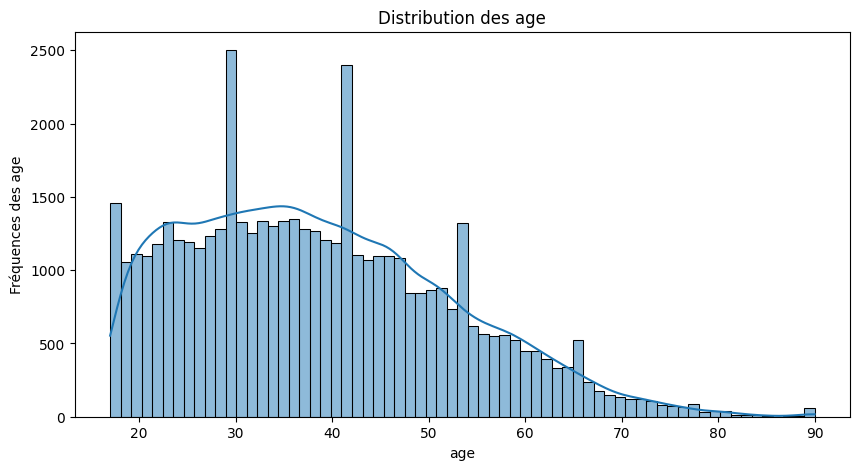

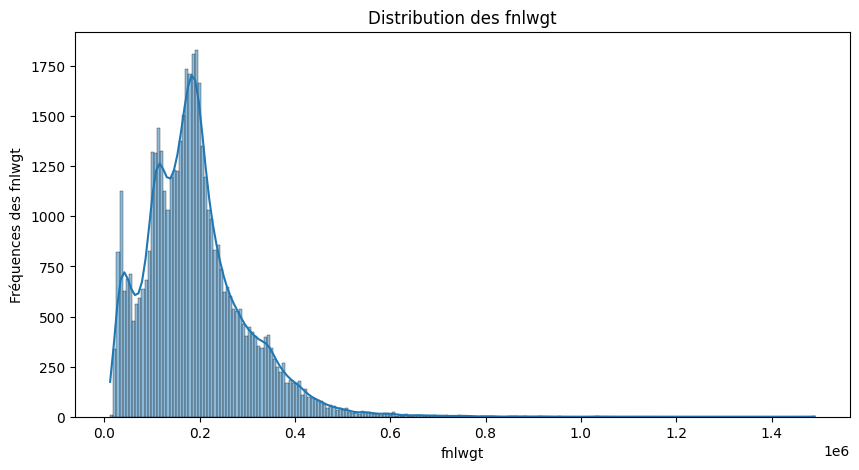

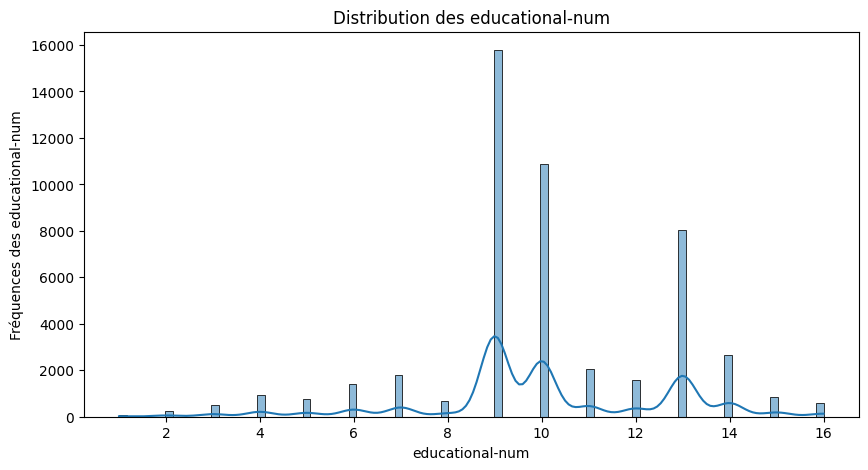

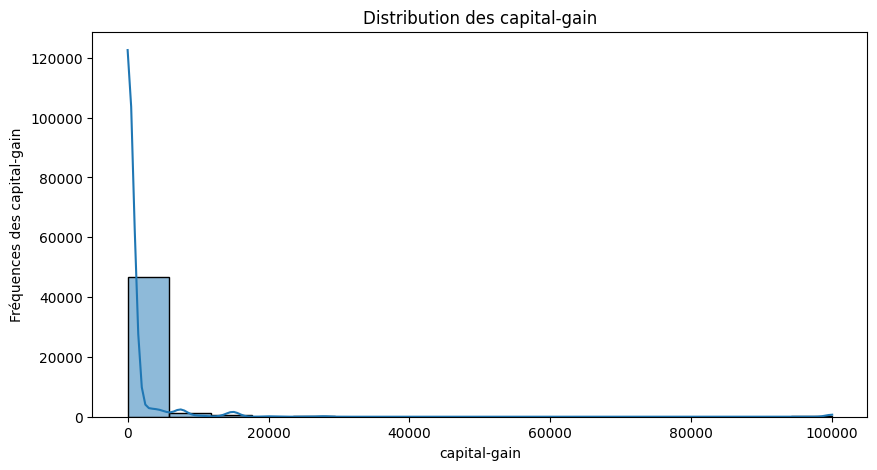

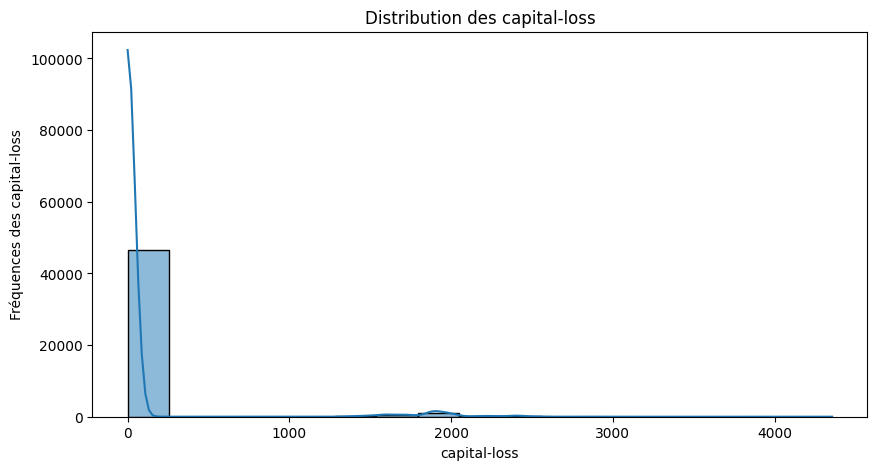

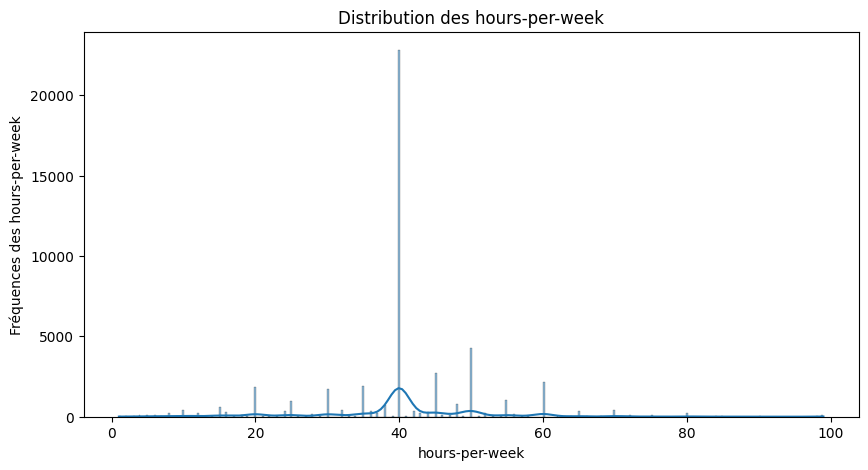

In [ ]:
#visualisation des attributs numériques du dataset revenu
colonne = revenu_df_copy.select_dtypes(include=['int64']).columns
for columns in colonne:
    plt.figure(figsize=(10,5))
    sns.histplot(revenu_df_copy[columns], kde=True)
    plt.title(f"Distribution des {columns}")
    plt.xlabel(columns)
    plt.ylabel(f"Fréquences des {columns}")
    plt.show()

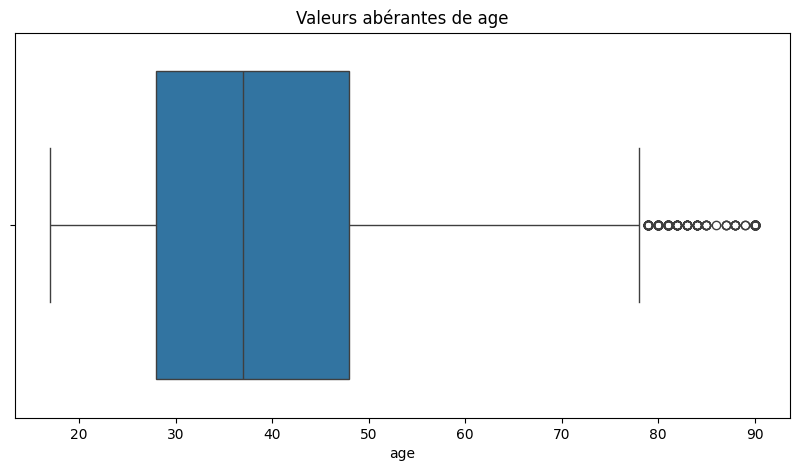

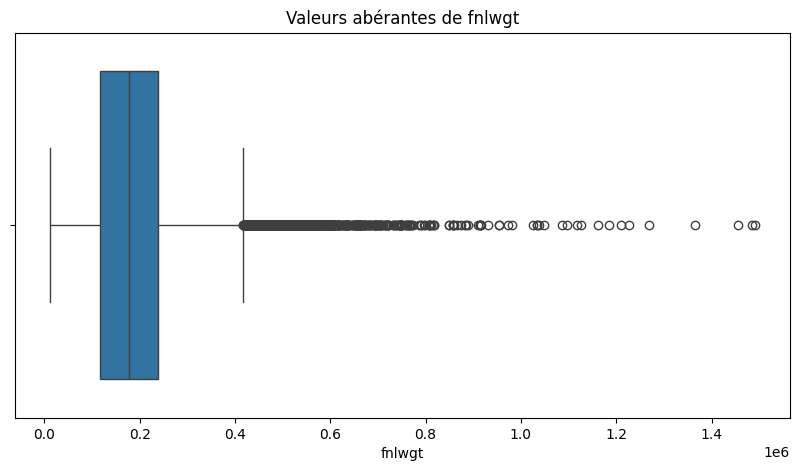

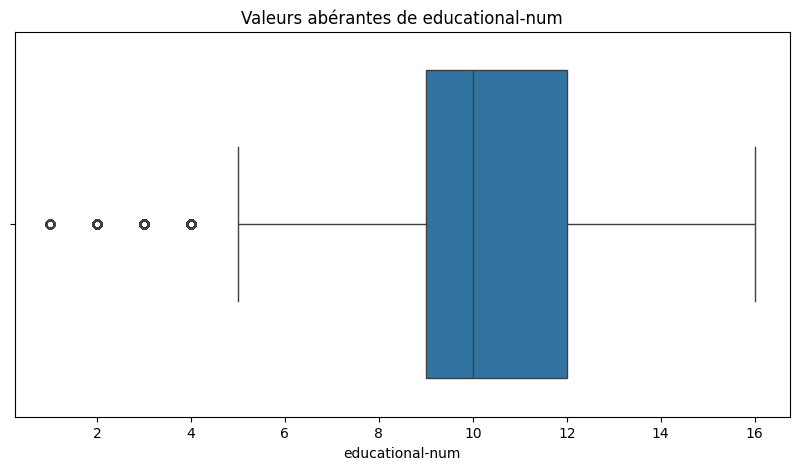

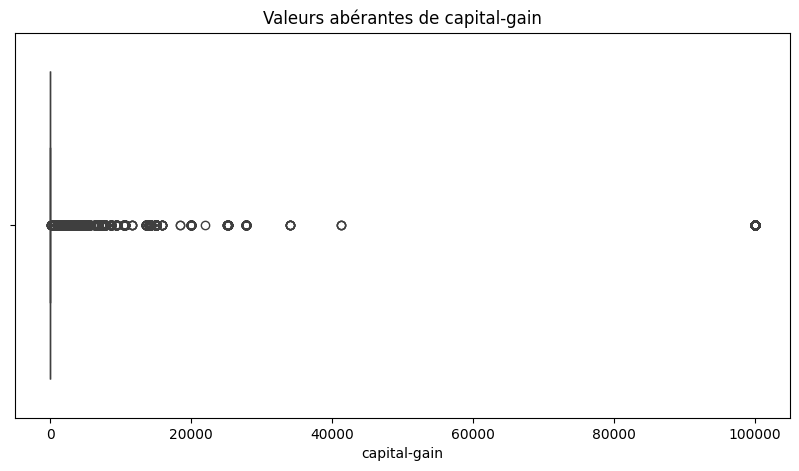

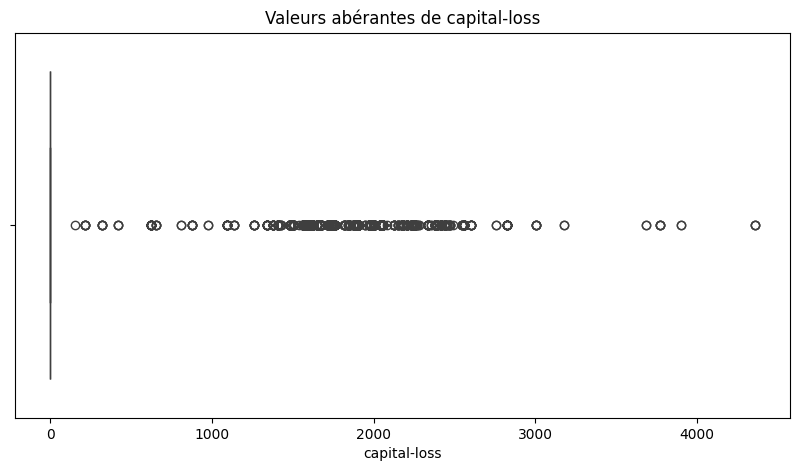

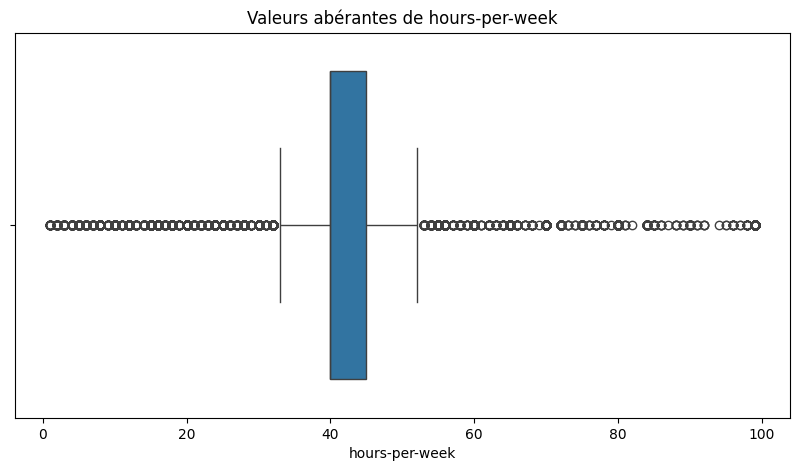

In [ ]:
#Détection de valeurs abérantes des attributs numériques du dataset revenu
colonne = revenu_df_copy.select_dtypes(include=['int64']).columns
for columns in colonne:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=revenu_df_copy[columns])
    plt.title(f"Valeurs abérantes de {columns}")
    plt.xlabel(columns)
    plt.show()

##### Quels sont les attributs numériques dans lesquels il manque des valeurs?

In [ ]:
print("Il n'a aucun attribut numérique dans lequel il manque des valeurs ")

Il n'a aucun attribut numérique dans lequel il manque des valeurs 


##### Comment sont répartis les attributs catégoriels dans le dataset?

In [ ]:
# On affiche les statistiques de distribution des attributs non numériques du dataset revenu
revenu_df_copy[['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'education']].describe()
#print(f'Statistique descriptive des attributs non numériques\n-----------------------------------------------------\n{revenu_df_copy[['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'education']].describe()}')

,workclass,marital-status,occupation,relationship,race,gender,native-country,education
count,46043,48842,46033,48842,48842,48842,47985,48842
unique,8,7,14,6,5,2,41,16
top,Private,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,HS-grad
freq,33906,22379,6172,19716,41762,32650,43832,15784


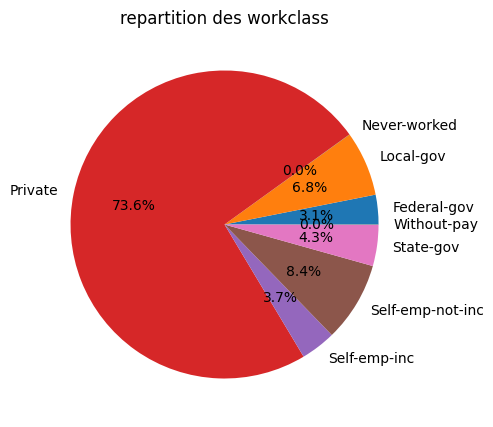

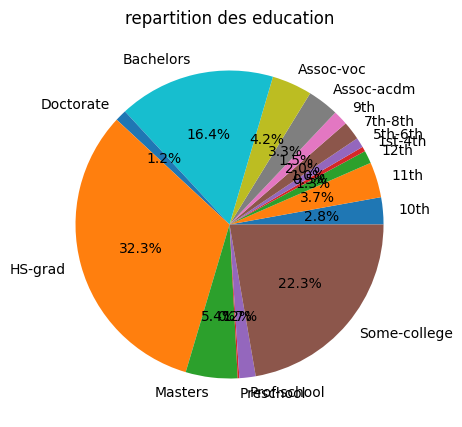

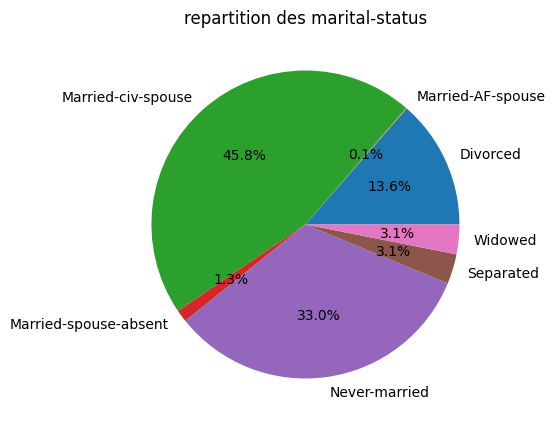

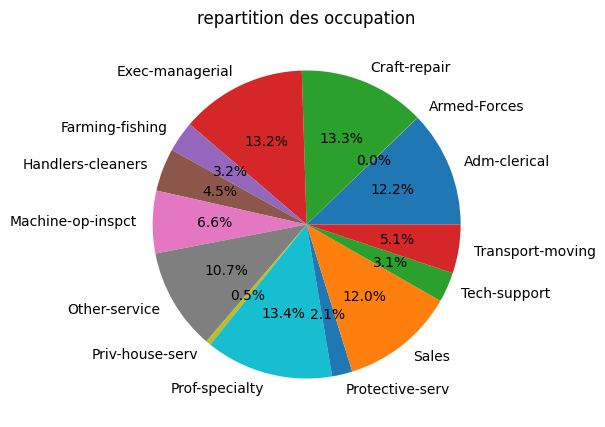

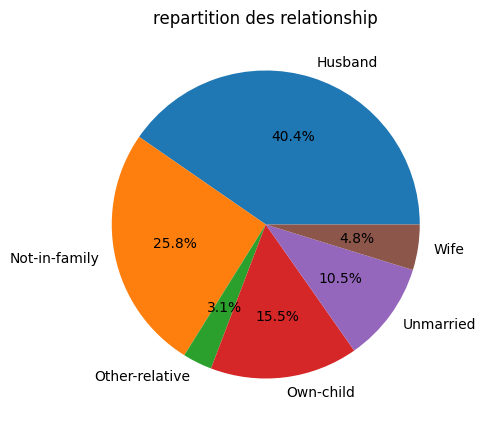

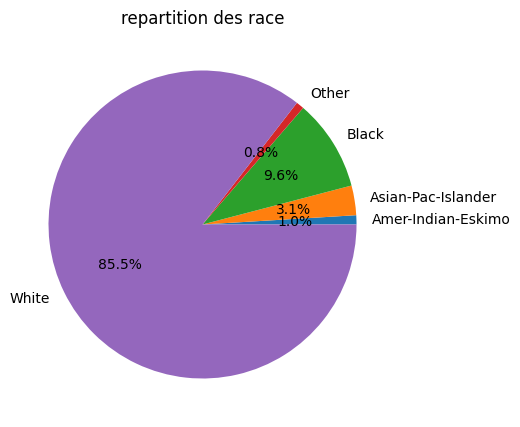

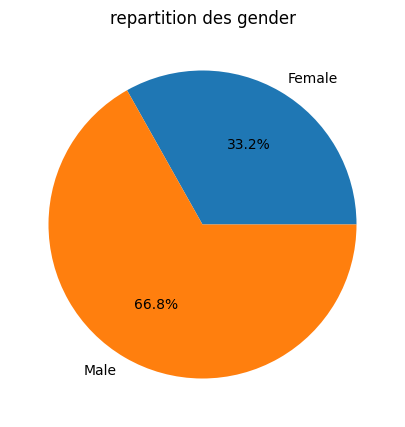

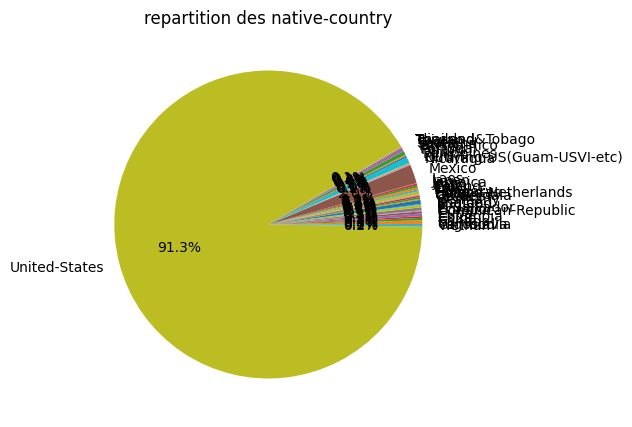

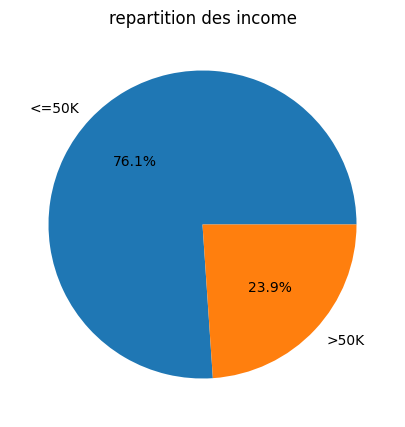

In [ ]:
# Affichons les categories des attributs catégoriels
colonne_categorielle = revenu_df_copy.select_dtypes(include='object').columns
for columns in colonne_categorielle:
    df_category = revenu_df_copy.groupby(columns).size()
    plt.figure(figsize=(10,5))
    df_category.plot.pie(autopct='%1.1f%%', title=f"repartition des {columns}")
    plt.show()

##### Quels sont les attributs catégoriels dans lesquels il manque des valeurs? 

In [ ]:
print("""\nLes attributs avec des données manquantes sont:\n-workclass\n-occupation\n-native-country""")


Les attributs avec des données manquantes sont:
-workclass
-occupation
-native-country


##### Combien de valeurs manquent ils dans les attributs pour lesquels certaines valeurs sont manquantes? 

In [ ]:
df_missing_values_revenu = revenu_df_copy.isnull().sum()
for columns in revenu_df_copy:
    missing_value = df_missing_values_revenu[columns]
    if (missing_value > 0) :
        print(f"{columns:15}: {missing_value:10}")
    

workclass      :       2799
occupation     :       2809
native-country :        857


##### Combien de fois dans le dataset avons nous à la fois workclass et occupation qui sont nulles en même temps?

In [ ]:
# On compte le nombre de ligne ou a la fois workclass et occupation sont null
filtre_workclass_occupation_null = revenu_df_copy['workclass'].isnull() & revenu_df_copy['occupation'].isnull()
print(f"workclass nulle | occupation nulle:{filtre_workclass_occupation_null.sum():5} entrées")

workclass nulle | occupation nulle: 2799 entrées


##### Y a t'il des entrées pour lesquelles workclass est nulle et occupation est non nulle?

In [ ]:
# Verifions les valeurs de occupation chaque fois que workclass est nulle
filtre_workclass_null_occupation_notnull = revenu_df_copy['workclass'].isnull() & revenu_df_copy['occupation'].notnull()
print(f"workclass nulle | occupation non nulle:{filtre_workclass_null_occupation_notnull.sum():5} entrées")

workclass nulle | occupation non nulle:    0 entrées


##### Y a t'il des entrées pour lesquelles workclass est non nulle et occupation est nulle?

In [ ]:
# Verifions les valeurs de workclass lorsque occupation est null
filtre_workclass_notnull_occupation_null = revenu_df_copy['occupation'].isnull() & revenu_df_copy['workclass'].notnull()
print(f"workclass non nulle | occupation nulle:{filtre_workclass_notnull_occupation_null.sum():5} entrées")

workclass non nulle | occupation nulle:   10 entrées


##### Quels sont les valeurs non nulles de workclass lorsque occupation est nulle? Sont elles abérantes?

In [ ]:
# Affichons les valeurs lorsque occupation est nulle et workclass est non nulle
df_type_wc_not_nul_when_ocup_nul = revenu_df_copy.loc[filtre_workclass_notnull_occupation_null].groupby('workclass').size()
for index, values in df_type_wc_not_nul_when_ocup_nul.items():
    print(f"{index:10}:{values:5}")
    
print("""\nOn remarque: quand occupation est nulle et workclass non nulle, workclass représente des gens qui n'ont jamais travailler.
Les valeurs manquantes de workclass et occupation ne seront pas considéré comme des erreurs d'entrées.
Elles ne sont pas abérantes.""")


Never-worked:   10

On remarque: quand occupation est nulle et workclass non nulle, workclass représente des gens qui n'ont jamais travailler.
Les valeurs manquantes de workclass et occupation ne seront pas considéré comme des erreurs d'entrées.
Elles ne sont pas abérantes.


##### Quelle informations nous amène la variables 'fnlwgt'?

In [ ]:
print("L'attribut nous amène le nombre d'individu dans une population qui sont représenté par l'entrée associé. Prenons l'exemple de la première entrée.\n")
print(f"1ère entrée:\n------------------\n{revenu_df_copy.iloc[0,:]}")
print("\n226802 personnes dans la population ont 25 ans travaillent dans le  privé on comme niveau d'éducation le '11th grade' etc")

L'attribut nous amène le nombre d'individu dans une population qui sont représenté par l'entrée associé. Prenons l'exemple de la première entrée.

1ère entrée:
------------------
age                               25
workclass                    Private
fnlwgt                        226802
education                       11th
educational-num                    7
marital-status         Never-married
occupation         Machine-op-inspct
relationship               Own-child
race                           Black
gender                          Male
capital-gain                       0
capital-loss                       0
hours-per-week                    40
native-country         United-States
income                         <=50K
Name: 0, dtype: object

226802 personnes dans la population ont 25 ans travaillent dans le  privé on comme niveau d'éducation le '11th grade' etc


##### De quels types d'attributs avons nous besoin pour prédire les revenus d'un individu?

In [ ]:
print("""Pour le jeu de données permettant d'entrainer un modèle a prédire si un individu fait +/- de 50k par année nous avons besoin de variables descriptives.
Pour l'analyse qui va se faire par la suite par les experts la variable de poids 'fnlwgt' nous permettra toutefois de pondéré certaine information sur le pourcentage de la population visé.
La variable n'amène aucun caractère descriptif supplémentaire. Dupliquer les lignes au nombre de la valeurs de 'fnlwgt de l'entrée donnerais un dataset beaucoup trop volumineux et peu d'information supplémentaire

On va donc retirer cette attribut pour l'entrainement des modèles.""")

Pour le jeu de données permettant d'entrainer un modèle a prédire si un individu fait +/- de 50k par année nous avons besoin de variables descriptives.
Pour l'analyse qui va se faire par la suite par les experts la variable de poids 'fnlwgt' nous permettra toutefois de pondéré certaine information sur le pourcentage de la population visé.
La variable n'amène aucun caractère descriptif supplémentaire. Dupliquer les lignes au nombre de la valeurs de 'fnlwgt de l'entrée donnerais un dataset beaucoup trop volumineux et peu d'information supplémentaire

On va donc retirer cette attribut pour l'entrainement des modèles.


In [ ]:
# Analysons les valeurs du dataset ou a la fois workclass occupation et native-country sont nulles
filtre_all_null = revenu_df_copy['native-country'].isnull() & revenu_df_copy['occupation'].isnull() & revenu_df_copy['workclass'].isnull()
print(f"native-country nulle | workclass nulle | occupation nulle: {filtre_all_null.sum():10} entrées")

native-country nulle | workclass nulle | occupation nulle:         46 entrées


##### Est-il necessaire de conserver educational-num et education?

In [ ]:
# vérifions qu'il y a bien 16 entrées différentes pour educational-num et pour 'education'
nb_unique_element_education =revenu_df_copy['education'].unique().size
print(f"Il y a {nb_unique_element_education} entrées différentes dans l'attribut education")
nb_unique_element_educational_num = revenu_df_copy['educational-num'].unique()
nb_unique_element_educational_num.sort()
value = 1
for number in nb_unique_element_educational_num:
    verified = True
    if number != value:
        verified = False
        break
    value = value + 1

value = value - 1 
if verified:
    print("Il y a bien 16 entrées différentes dans l'attribut educational-num de [1,16]")
else:
    print("Il n'y a pas 16 entrées différentes dans l'attribut educational-num de [1,16]")
  
if value == nb_unique_element_education:
    print("Il n'est pas necessaire de conserver les deux attributs\nNous pouvons simplement conserver educationnal-num")
    

Il y a 16 entrées différentes dans l'attribut education
Il y a bien 16 entrées différentes dans l'attribut educational-num de [1,16]
Il n'est pas necessaire de conserver les deux attributs
Nous pouvons simplement conserver educationnal-num


#### age

##### Quelle est la corrélation entre l'age et le revenu?

In [ ]:
# Quelle est la corrélation entre le educational-num et le revenu
matrice_de_correlation_corr_age_revenu = revenu_df_final[['age', 'income_encoded']]
corr_age_revenu = matrice_de_correlation_corr_age_revenu.copy().corr(method='spearman')
corr_age_revenu

,age,income_encoded
age,1.000000,0.269433
income_encoded,0.269433,1.000000


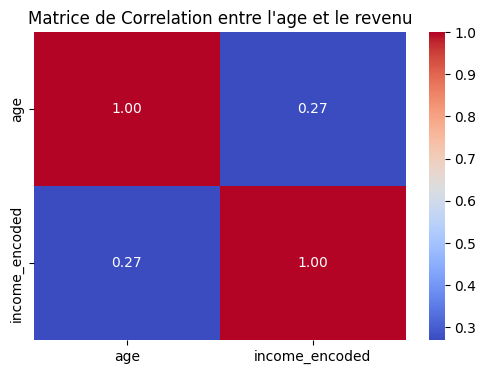

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_age_revenu, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation entre l'age et le revenu")
plt.show()
# Correlation positive entre l'age eleve et avoir un salaire superieur à 50k(1 dans encoded_income)

#### educational-num

##### Quelle est la corrélation entre le educational-num et le revenu?

In [ ]:
# Quelle est la corrélation entre le educational-num et le revenu
matrice_de_correlation_educational_num = revenu_df_final[['educational-num', 'income_encoded']]
corr_educational_num = matrice_de_correlation_educational_num.copy().corr(method='spearman')
corr_educational_num

,educational-num,income_encoded
educational-num,1.000000,0.327815
income_encoded,0.327815,1.000000


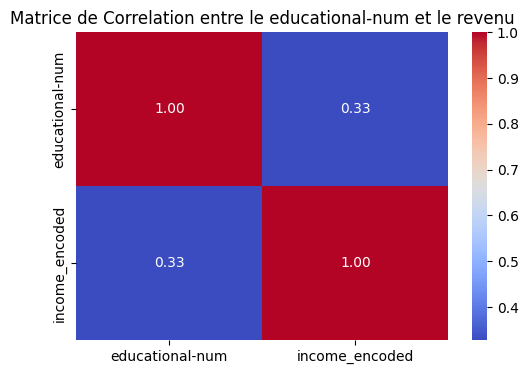

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_educational_num, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation entre le educational-num et le revenu")
plt.show()
# Correlation positive entre le fait d'avoir un niveau d'education eleve et avoir un salaire superieur à 50k(1 dans encoded_income)

#### hours-per-week

##### Quelle est la corrélation entre hours-per-week et le revenu?

In [ ]:
# Quelle est la corrélation entre hours-per-week et le revenu
matrice_de_correlation_corr_hr_week_revenu = revenu_df_final[['hours-per-week', 'income_encoded']]
corr_hr_week_revenu = matrice_de_correlation_corr_hr_week_revenu.copy().corr(method='spearman')
corr_hr_week_revenu

,hours-per-week,income_encoded
hours-per-week,1.000000,0.268166
income_encoded,0.268166,1.000000


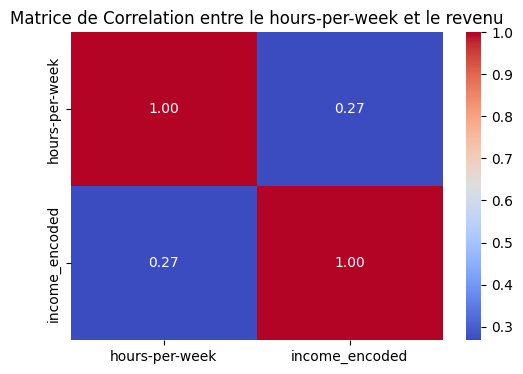

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_hr_week_revenu, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation entre le hours-per-week et le revenu")
plt.show()

#### capital-gain/capital-loss

##### Quelle est la proportion du dataset qui ont soumis une entrée pour capital-gain et capital-loss?

In [ ]:
nb_null_entries_capital_gain = revenu_df_copy.loc[revenu_df_copy['capital-gain'] == 0]['capital-gain'].count()
nb_not_null_entries_capital_gain = revenu_df_copy.loc[revenu_df_copy['capital-gain'] != 0]['capital-gain'].count()
print(f"{("Entrées nulle de capital-gain"):35} {nb_null_entries_capital_gain:10}")
print(f"{("Entrées non nulle de capital-gain:"):35} {nb_not_null_entries_capital_gain:10}")
nb_null_entries_capital_loss = revenu_df_copy.loc[revenu_df_copy['capital-loss'] == 0]['capital-loss'].count()
nb_not_null_entries_capital_loss = revenu_df_copy.loc[revenu_df_copy['capital-loss'] != 0]['capital-loss'].count()
print(f"{("Entrées nulle de capital-loss"):35} {nb_null_entries_capital_loss:10}")
print(f"{("Entrées non nulle de capital-loss:"):35} {nb_not_null_entries_capital_loss:10}")

Entrées nulle de capital-gain            44807
Entrées non nulle de capital-gain:        4035
Entrées nulle de capital-loss            46560
Entrées non nulle de capital-loss:        2282


##### Quelle est la corrélation entre le gain de capital et avoir un revenu supérieur à 50k?

In [ ]:
# Quelle est la corrélation entre l'age' et le revenu
matrice_de_correlation_corr_capital_gain_revenu = revenu_df_final[['capital-gain', 'income_encoded']]
corr_capital_gain_revenu = matrice_de_correlation_corr_capital_gain_revenu.copy().corr(method='spearman')
corr_capital_gain_revenu

,capital-gain,income_encoded
capital-gain,1.000000,0.277734
income_encoded,0.277734,1.000000


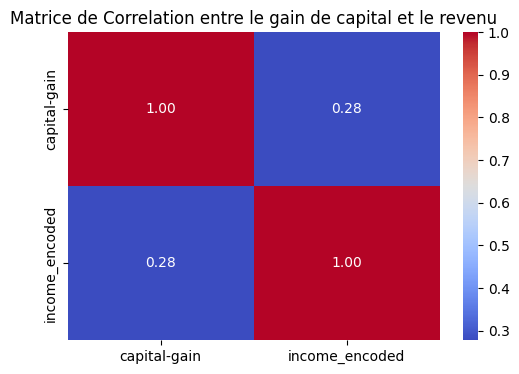

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_capital_gain_revenu, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation entre le gain de capital et le revenu")
plt.show()
# Correlation positive entre le fait d;avoir un gain de capital et avoir un salaire superieur à 50k(1 dans encoded_income)

##### Quelle est la corrélation entre la perte de capital et avoir un revenu supérieur à 50k?

In [ ]:
# Quelle est la corrélation entre l'age' et le revenu
matrice_de_correlation_corr_capital_loss_revenu = revenu_df_final[['capital-loss', 'income_encoded']]
corr_capital_loss_revenu = matrice_de_correlation_corr_capital_loss_revenu.copy().corr(method='spearman')
corr_capital_loss_revenu

,capital-loss,income_encoded
capital-loss,1.000000,0.138248
income_encoded,0.138248,1.000000


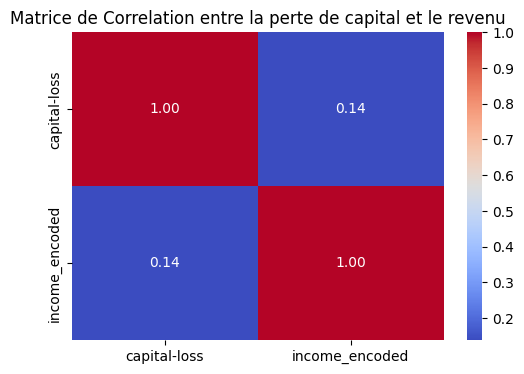

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_capital_loss_revenu, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation entre la perte de capital et le revenu")
plt.show()
# Correlation positive mais très faible entre le fait d'avoir une perte de capital et avoir un salaire superieur à 50k(1 dans encoded_income)

In [ ]:
# On concatène toutes les colonnes sélectionné dans le prétraitement et on crée le df final 'revenu_df_processed_final'
revenu_df_final = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender,df_normalised_capital_gain, df_normalised_capital_loss,revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)
revenu_df_final.iloc[:,: 100] # jusqu'a income_encoded
revenu_df_final_without_capital = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender, revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)
revenu_df_final_with_modified_capital_gain = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender, df_has_a_gain, revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)
revenu_df_final_with_modified_capital_gain_capital_loss = pd.concat([revenu_df_processed.iloc[:,:27], df_encoded_relationship, df_encoded_race, df_encoded_gender, df_has_a_gain, df_has_a_loss, revenu_df_copy['hours-per-week'], df_encoded_native_country, revenu_df_processed['income_encoded']], axis=1)


## Équilibrage des classes Revenu

#### Séparation du dataset pour les données d'apprentissage

In [ ]:
#Separation du dataset X et Y(Input/Output)
X_revenu = revenu_df_final.iloc[:,: -1]
Y_revenu = revenu_df_final.iloc[:, -1]
#X_revenu = revenu_df_final_without_capital.iloc[:,: -1]
#Y_revenu = revenu_df_final_without_capital.iloc[:, -1]
#X_revenu = revenu_df_final_with_modified_capital_gain.iloc[:,: -1]
#Y_revenu = revenu_df_final_with_modified_capital_gain.iloc[:, -1]
#X_revenu = revenu_df_final_with_modified_capital_gain_capital_loss.iloc[:,: -1]
#Y_revenu = revenu_df_final_with_modified_capital_gain_capital_loss.iloc[:, -1]

#Séparation en 70 % train / 30 % test
X_train_revenu, X_test_revenu, Y_train_revenu, Y_test_revenu = train_test_split(X_revenu, Y_revenu, test_size=0.3, random_state=15)

#### Diagnostique du déséquilibre

In [ ]:
#Diagnostique du déséquilibre avant équilibrage
print("Diagnostique du déséquilibre de la cible à prédire avant équilibrage\n--------------------------------------------------------------------\n")
counts_before_revenu = Y_revenu.value_counts()
ratio_before_revenu = counts_before_revenu.min()/counts_before_revenu.max()
print(counts_before_revenu)
print(f"\nLe ratio de déséquilibre de la classe minoritaire est {ratio_before_revenu:.2f}")

Diagnostique du déséquilibre de la cible à prédire avant équilibrage
--------------------------------------------------------------------

income_encoded
0    37155
1    11687
Name: count, dtype: int64

Le ratio de déséquilibre de la classe minoritaire est 0.31


In [ ]:
#Sélection de la classe minoritaire et séparation du dataset en X et Y(Input/Output)
X_revenu_classe_minoritaire = revenu_df_final.loc[revenu_df_final['income_encoded'] == 1].iloc[:,: -1]
Y_revenu_classe_minoritaire = revenu_df_final.loc[revenu_df_final['income_encoded'] == 1].iloc[:, -1]

#### Équilibrage classe avec RandomUnderSampler

In [ ]:
#Definition de la fonction de réquilibrage RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

#Application de la fonction de reéquilibrage
X_rus_revenu, Y_rus_revenu = rus.fit_resample(X_train_revenu, Y_train_revenu)
counts_after_rus_revenu = Y_rus_revenu.value_counts()
ratio_after_rus_revenu = counts_after_rus_revenu.min()/counts_after_rus_revenu.max()

#Diagnostique du déséquilibre Avant/Après équilibrage
print("Diagnostique du déséquilibre de la cible à prédire avant équilibrage avec RandomUnderSampler\n--------------------------------------------------------------------------------------------\n")
print(counts_after_rus_revenu)
print(f"\nLe ratio de déséquilibre de la classe minoritaire après équilibrage est maintenant {ratio_after_rus_revenu:.2f}")

Diagnostique du déséquilibre de la cible à prédire avant équilibrage avec RandomUnderSampler
--------------------------------------------------------------------------------------------

income_encoded
0    8122
1    8122
Name: count, dtype: int64

Le ratio de déséquilibre de la classe minoritaire après équilibrage est maintenant 1.00


##### Observations des attributs avec le plus de outliers après équilibrage avec RandomUnderSampler

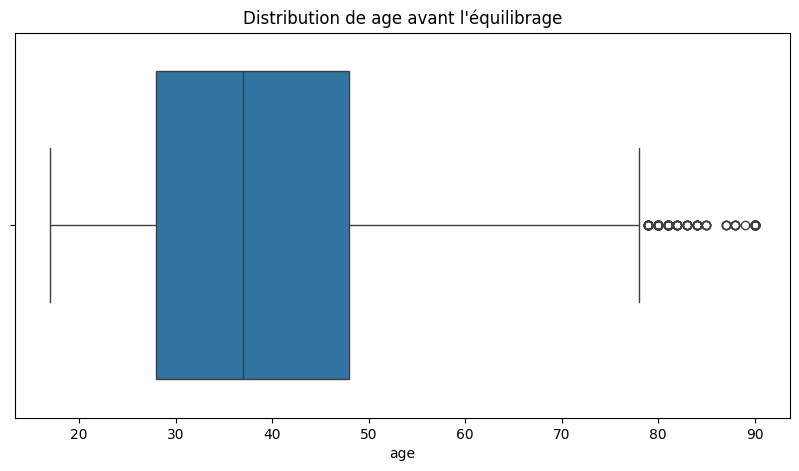

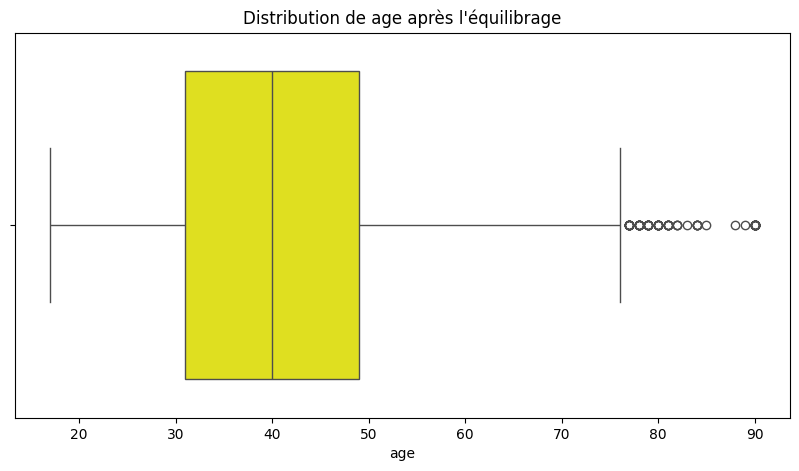

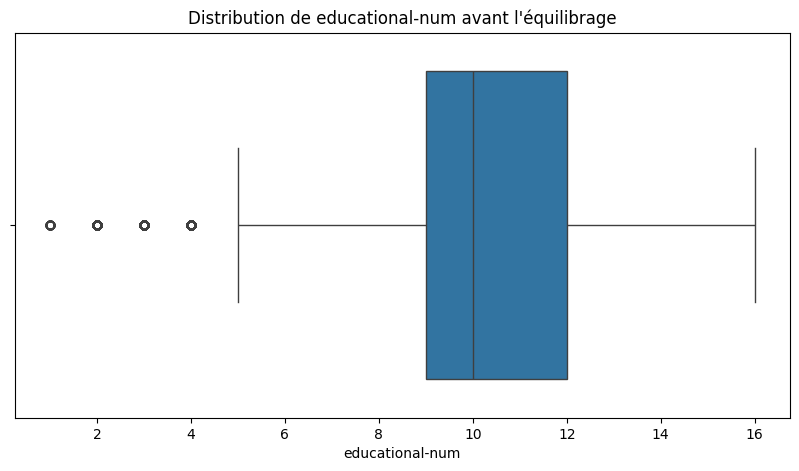

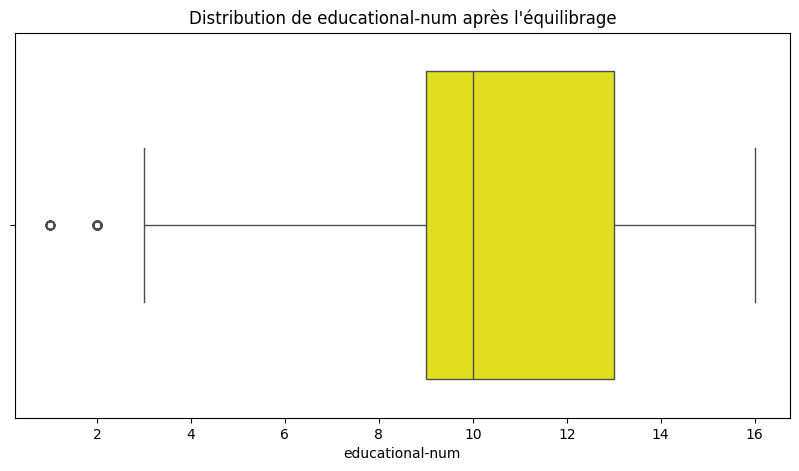

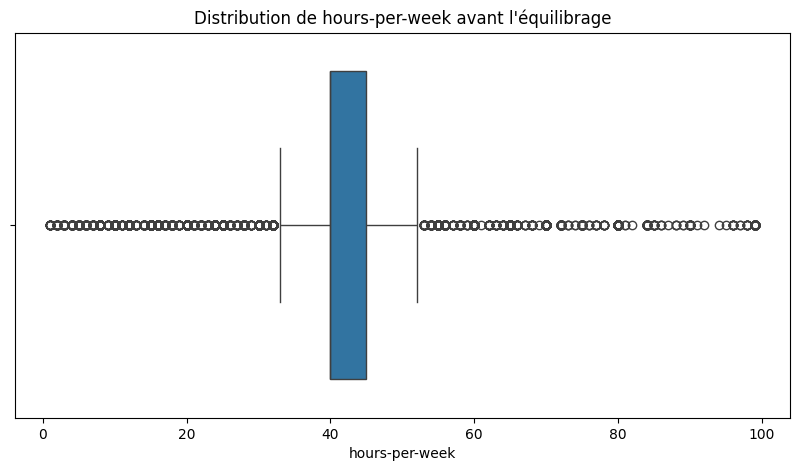

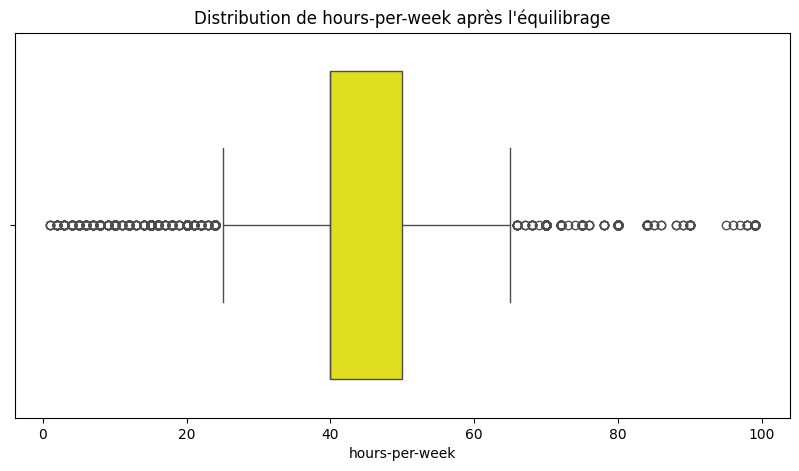

In [ ]:
# On veut observer age, capital-gain, capital-loss, educational-num, hours-per-week
#colonne_revenu_numerique_after_rus = X_rus_revenu.loc[:, ['age', 'capital-gain', 'capital-loss', 'educational-num', 'hours-per-week']]
#colonne_revenu_numerique_before_rus = X_train_revenu.loc[:, ['age', 'capital-gain', 'capital-loss', 'educational-num', 'hours-per-week']]
colonne_revenu_numerique_after_rus = X_rus_revenu.loc[:, ['age', 'educational-num', 'hours-per-week']]
colonne_revenu_numerique_before_rus = X_train_revenu.loc[:, ['age','educational-num', 'hours-per-week']]

for columns in colonne_revenu_numerique_after_rus:
    plt.figure(figsize=(10,5))
    sns.boxplot(x = X_train_revenu[columns])
    plt.title(f"Distribution de {columns} avant l'équilibrage")
    plt.show()
    plt.figure(figsize=(10,5))
    sns.boxplot(x = X_rus_revenu[columns], color='yellow')
    plt.title(f"Distribution de {columns} après l'équilibrage")
    plt.show()

#### Analyse de l'équilibrage

In [ ]:
# Description de la distribution des attributs avant l'équilibrage
#X_train_revenu.loc[:, ['age', 'capital-gain', 'capital-loss', 'educational-num', 'hours-per-week']].describe()
X_train_revenu.loc[:, ['age','educational-num', 'hours-per-week']].describe()

,age,educational-num,hours-per-week
count,34189.000000,34189.000000,34189.000000
mean,38.586241,10.070578,40.351487
std,13.744472,2.567907,12.362442
min,17.000000,1.000000,1.000000
25%,28.000000,9.000000,40.000000
50%,37.000000,10.000000,40.000000
75%,48.000000,12.000000,45.000000
max,90.000000,16.000000,99.000000


In [ ]:
# Description de la distribution des attributs après l'équilibrage
X_rus_revenu.loc[:, ['age','educational-num', 'hours-per-week']].describe()

,age,educational-num,hours-per-week
count,16244.000000,16244.000000,16244.000000
mean,40.511758,10.586309,42.151441
std,13.015675,2.605054,12.169814
min,17.000000,1.000000,1.000000
25%,31.000000,9.000000,40.000000
50%,40.000000,10.000000,40.000000
75%,49.000000,13.000000,50.000000
max,90.000000,16.000000,99.000000


## Modélisation supervisée Revenu

#### Apprentissage supervisé

In [ ]:
# On cree une liste de modeles en tuples
models = []
models.append(('LR', LogisticRegression(solver='newton-cg')))
models.append(('DT', DecisionTreeClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC(probability=True)))
models.append(('NB', GaussianNB()))
models.append(('GB', GradientBoostingClassifier()))

# On cree une liste de metriques en tuples
metrics = []
metrics.append(('Accuracy', accuracy_score))
metrics.append(('Precision', precision_score))
metrics.append(('Recall', recall_score))
metrics.append(('F1-score', f1_score))
metrics.append(('AUC-ROC', roc_auc_score))

#Création d'un tableau comparatif des des scores par modèle et par méthode de validation
df_comparaison_revenu = pd.DataFrame(columns=['modele', 'metrique', 'methode-de-validation', 'score', 'score-train'])

In [ ]:
#Verification des scores par modèle et par métrique
for models_name, model in models:
    model.fit(X_rus_revenu, Y_rus_revenu)
    Y_prediction_revenu = (model.predict_proba(X_test_revenu)[:,1] >= 0.5).astype(int)
    Y_train_prediction_revenu = (model.predict_proba(X_rus_revenu)[:,1] >= 0.5).astype(int)
    for metrics_name, metric in metrics:
        comparaison_modele_ajout = pd.DataFrame({'modele': [models_name], 'metrique': [metrics_name], 'methode-de-validation': ['70 % train / 30 % test'], 'score': [metric(Y_test_revenu.values,Y_prediction_revenu)*100], 'score-train': [metric(Y_rus_revenu,Y_train_prediction_revenu)*100]})
        df_comparaison_revenu = pd.concat([df_comparaison_revenu,comparaison_modele_ajout], ignore_index=True)
        
    

/var/folders/1g/cphp03qd215btnhr3lkgl4qw0000gn/T/ipykernel_35945/1076689580.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparaison_revenu = pd.concat([df_comparaison_revenu,comparaison_modele_ajout], ignore_index=True)


#### Validation croisée

In [ ]:
# metriques
scoring = {
    'accuracy'  : make_scorer(accuracy_score),
    'Precision' : make_scorer(precision_score),
    'Recall'    : make_scorer(recall_score),
    'F1-score'  : make_scorer(f1_score),
    'AUC-ROC'   : make_scorer(roc_auc_score)
}

# Stratified K-Fold
five_f = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
seven_f = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
ten_f = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
strat = [five_f, seven_f, ten_f]

for cv in strat:
    for model_name, model in models:
        pipe = ImbPipeline(steps=[('RandomUnderSampler',RandomUnderSampler(random_state=42)),(model_name, model) ])
        validations = cross_validate(
            pipe, X_revenu, Y_revenu,
            cv = cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )
        for metric in scoring:
            scores = validations[f'test_{metric}']
            score_train = validations[f'train_{metric}']
            comparaison_modele_ajout = pd.DataFrame({'modele': [model_name], 'metrique': [metric], 'methode-de-validation': [f"Cross validation de {cv.n_splits} folds"], 'score': [scores.mean()*100], 'score-train': [score_train.mean()*100]})
            df_comparaison_revenu = pd.concat([df_comparaison_revenu,comparaison_modele_ajout], ignore_index=True)




#### Vérification de performance sur le Dataset des valeurs de la classe minoritaire

In [ ]:
df_comparaison_revenu_classe_minoritaire = pd.DataFrame(columns=['modele', 'metrique', 'score'])

In [ ]:
#Verification des scores par modèle et par métrique
for models_name, model in models:
    Y_prediction_revenu_classe_minoritaire = (model.predict_proba(X_revenu_classe_minoritaire)[:,1] >= 0.5).astype(int)
    #Y_train_prediction_credit = (model.predict_proba(X_ros_credit)[:,1] >= 0.5).astype(int)
    for metrics_name, metric in metrics:
        comparaison_modele_revenu_classe_minoritaire_ajout = pd.DataFrame({'modele': [models_name], 'metrique': [metrics_name],'score': [metric(Y_revenu_classe_minoritaire.values,Y_prediction_revenu_classe_minoritaire)*100]})
        df_comparaison_revenu_classe_minoritaire = pd.concat([df_comparaison_revenu_classe_minoritaire,comparaison_modele_revenu_classe_minoritaire_ajout], ignore_index=True)

/var/folders/1g/cphp03qd215btnhr3lkgl4qw0000gn/T/ipykernel_35945/2362093317.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparaison_revenu_classe_minoritaire = pd.concat([df_comparaison_revenu_classe_minoritaire,comparaison_modele_revenu_classe_minoritaire_ajout], ignore_index=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  wa

In [ ]:
df_comparaison_revenu_classe_minoritaire

,modele,metrique,score
0,LR,Accuracy,84.906306
1,LR,Precision,100.000000
2,LR,Recall,84.906306
3,LR,F1-score,91.837112
4,LR,AUC-ROC,NaN
5,DT,Accuracy,93.548387
6,DT,Precision,100.000000
7,DT,Recall,93.548387
8,DT,F1-score,96.666667
9,DT,AUC-ROC,NaN


## Évaluation & comparaison

#### Analyse du modèle Régression Logistique

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'LR']

,modele,metrique,methode-de-validation,score,score-train
0,LR,Accuracy,70 % train / 30 % test,80.973180,82.005664
1,LR,Precision,70 % train / 30 % test,57.312253,80.378637
2,LR,Recall,70 % train / 30 % test,85.413745,84.683575
3,LR,F1-score,70 % train / 30 % test,68.596531,82.474969
4,LR,AUC-ROC,70 % train / 30 % test,82.479600,82.005664
35,LR,accuracy,Cross validation de 5 folds,80.672382,80.760411
36,LR,Precision,Cross validation de 5 folds,56.413814,56.526590
37,LR,Recall,Cross validation de 5 folds,84.649674,84.857111
38,LR,F1-score,Cross validation de 5 folds,67.703194,67.853265
39,LR,AUC-ROC,Cross validation de 5 folds,82.035508,82.164459


#### Analyse du modèle Arbre de Décision

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'DT']

,modele,metrique,methode-de-validation,score,score-train
5,DT,Accuracy,70 % train / 30 % test,77.369822,97.248215
6,DT,Precision,70 % train / 30 % test,52.255843,95.559777
7,DT,Recall,70 % train / 30 % test,80.897616,99.101207
8,DT,F1-score,70 % train / 30 % test,63.496257,97.298277
9,DT,AUC-ROC,70 % train / 30 % test,78.566593,97.248215
40,DT,accuracy,Cross validation de 5 folds,77.240901,86.975863
41,DT,Precision,Cross validation de 5 folds,51.657700,65.453320
42,DT,Recall,Cross validation de 5 folds,76.589473,96.517497
43,DT,F1-score,Cross validation de 5 folds,61.693411,78.005910
44,DT,AUC-ROC,Cross validation de 5 folds,77.017654,90.246032


#### Analyse du modèle Random Forest

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'RF']

,modele,metrique,methode-de-validation,score,score-train
10,RF,Accuracy,70 % train / 30 % test,80.563707,97.248215
11,RF,Precision,70 % train / 30 % test,56.898211,96.385833
12,RF,Recall,70 % train / 30 % test,82.945302,98.177789
13,RF,F1-score,70 % train / 30 % test,67.496005,97.273559
14,RF,AUC-ROC,70 % train / 30 % test,81.371641,97.248215
45,RF,accuracy,Cross validation de 5 folds,80.574097,88.481736
46,RF,Precision,Cross validation de 5 folds,56.546932,67.992538
47,RF,Recall,Cross validation de 5 folds,81.312548,97.999915
48,RF,F1-score,Cross validation de 5 folds,66.700047,80.283475
49,RF,AUC-ROC,Cross validation de 5 folds,80.827180,91.743868


#### Analyse du modèle KNN

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'KNN']

,modele,metrique,methode-de-validation,score,score-train
15,KNN,Accuracy,70 % train / 30 % test,77.219682,83.710909
16,KNN,Precision,70 % train / 30 % test,52.172249,84.225000
17,KNN,Recall,70 % train / 30 % test,76.465638,82.959862
18,KNN,F1-score,70 % train / 30 % test,62.025028,83.587644
19,KNN,AUC-ROC,70 % train / 30 % test,76.963880,83.710909
50,KNN,accuracy,Cross validation de 5 folds,77.734336,80.881208
51,KNN,Precision,Cross validation de 5 folds,52.412851,56.909592
52,KNN,Recall,Cross validation de 5 folds,75.477071,82.799271
53,KNN,F1-score,Cross validation de 5 folds,61.863978,67.454365
54,KNN,AUC-ROC,Cross validation de 5 folds,76.960713,81.538581


#### Analyse du modèle SVM

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'SVM']

,modele,metrique,methode-de-validation,score,score-train
20,SVM,Accuracy,70 % train / 30 % test,79.492254,80.669786
21,SVM,Precision,70 % train / 30 % test,55.103901,78.757793
22,SVM,Recall,70 % train / 30 % test,84.796634,83.994090
23,SVM,F1-score,70 % train / 30 % test,66.799249,81.291706
24,SVM,AUC-ROC,70 % train / 30 % test,81.291715,80.669786
55,SVM,accuracy,Cross validation de 5 folds,78.366984,78.382334
56,SVM,Precision,Cross validation de 5 folds,52.939089,52.958600
57,SVM,Recall,Cross validation de 5 folds,86.395194,86.459316
58,SVM,F1-score,Cross validation de 5 folds,65.649700,65.683260
59,SVM,AUC-ROC,Cross validation de 5 folds,81.118469,81.150530


#### Analyse du modèle Naive Bayes

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'NB']

,modele,metrique,methode-de-validation,score,score-train
25,NB,Accuracy,70 % train / 30 % test,64.287177,74.242797
26,NB,Precision,70 % train / 30 % test,39.868805,67.614958
27,NB,Recall,70 % train / 30 % test,92.061711,93.055898
28,NB,F1-score,70 % train / 30 % test,55.641265,78.321244
29,NB,AUC-ROC,70 % train / 30 % test,73.709427,74.242797
60,NB,accuracy,Cross validation de 5 folds,65.460125,65.352035
61,NB,Precision,Cross validation de 5 folds,40.552650,40.421905
62,NB,Recall,Cross validation de 5 folds,92.196348,92.168678
63,NB,F1-score,Cross validation de 5 folds,56.242822,56.123899
64,NB,AUC-ROC,Cross validation de 5 folds,74.623272,74.542824


#### Analyse du modèle Gradient Boosting

In [ ]:
df_comparaison_revenu.loc[df_comparaison_revenu['modele'] == 'GB']

,modele,metrique,methode-de-validation,score,score-train
30,GB,Accuracy,70 % train / 30 % test,82.392684,83.981778
31,GB,Precision,70 % train / 30 % test,59.354226,81.951841
32,GB,Recall,70 % train / 30 % test,87.657784,87.158335
33,GB,F1-score,70 % train / 30 % test,70.781427,84.474940
34,GB,AUC-ROC,70 % train / 30 % test,84.178820,83.981778
65,GB,accuracy,Cross validation de 5 folds,81.990915,82.287787
66,GB,Precision,Cross validation de 5 folds,58.325170,58.759641
67,GB,Recall,Cross validation de 5 folds,86.694643,87.158824
68,GB,F1-score,Cross validation de 5 folds,69.732599,70.193920
69,GB,AUC-ROC,Cross validation de 5 folds,83.603007,83.957221
